In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
%matplotlib inline

In [2]:
# fetch_openml returns a pandas DataFrame – we convert to numpy
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_raw, y_raw = mnist.data, mnist.target.astype(int)

print(f"Shape X: {X_raw.shape}, Shape y: {y_raw.shape}")


Shape X: (70000, 784), Shape y: (70000,)


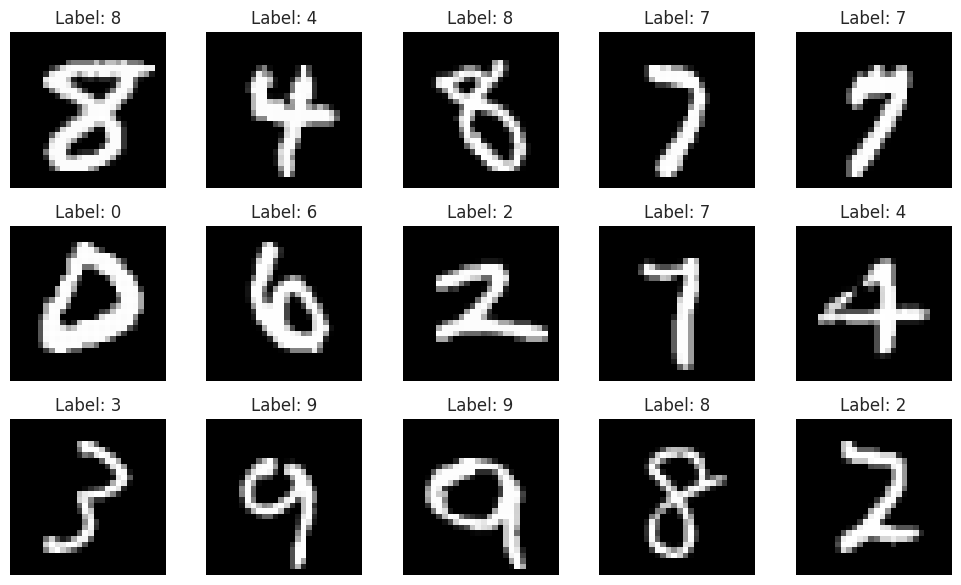

In [3]:
def plot_digits(X, y, indices, cols=5):
    rows = (len(indices) + cols - 1) // cols
    plt.figure(figsize=(cols*2, rows*2))
    for i, idx in enumerate(indices):
        plt.subplot(rows, cols, i+1)
        plt.imshow(X[idx].reshape(28,28), cmap='gray')
        plt.title(f'Label: {y[idx]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

np.random.seed(42)
sample_idx = np.random.choice(len(X_raw), 15, replace=False)
plot_digits(X_raw, y_raw, sample_idx)

In [4]:
# 1. Normalize
X = X_raw / 255.0

# 2. Train / validation / test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_raw, test_size=0.3, random_state=42, stratify=y_raw)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 49000, Val: 10500, Test: 10500


In [5]:
# LogisticRegression with 'ovr' = one-vs-rest, 'multinomial' + 'saga' works for softmax
logreg = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    max_iter=1000,
    tol=1e-3,
    C=1.0,
    n_jobs=-1,
    random_state=42
)

logreg.fit(X_train, y_train)

# Quick validation accuracy
val_acc = accuracy_score(y_val, logreg.predict(X_val))
print(f"Validation accuracy: {val_acc:.4f}")

Validation accuracy: 0.9177


In [6]:
y_pred = logreg.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc:.4f}\n")

print(classification_report(y_test, y_pred, digits=4))

Test accuracy: 0.9217

              precision    recall  f1-score   support

           0     0.9438    0.9739    0.9586      1035
           1     0.9551    0.9738    0.9644      1181
           2     0.9243    0.9075    0.9158      1049
           3     0.8943    0.8852    0.8897      1071
           4     0.9251    0.9170    0.9210      1024
           5     0.8852    0.8796    0.8824       947
           6     0.9401    0.9574    0.9486      1032
           7     0.9472    0.9351    0.9411      1094
           8     0.8898    0.8672    0.8783      1024
           9     0.9012    0.9099    0.9055      1043

    accuracy                         0.9217     10500
   macro avg     0.9206    0.9206    0.9206     10500
weighted avg     0.9215    0.9217    0.9215     10500



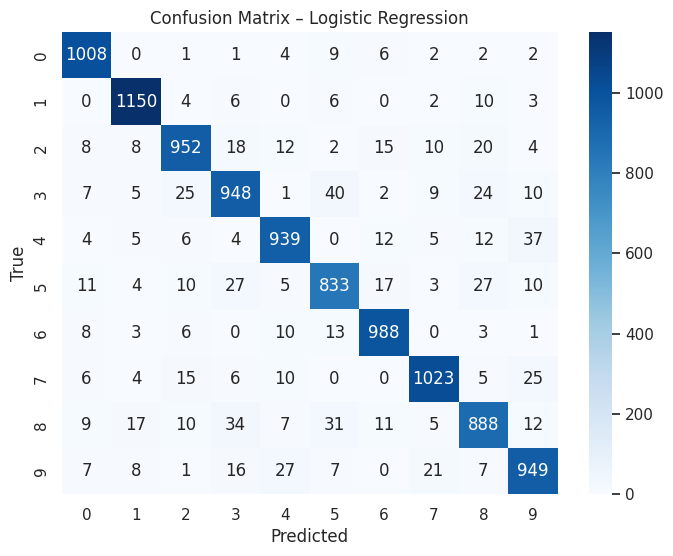

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – Logistic Regression')
plt.show()

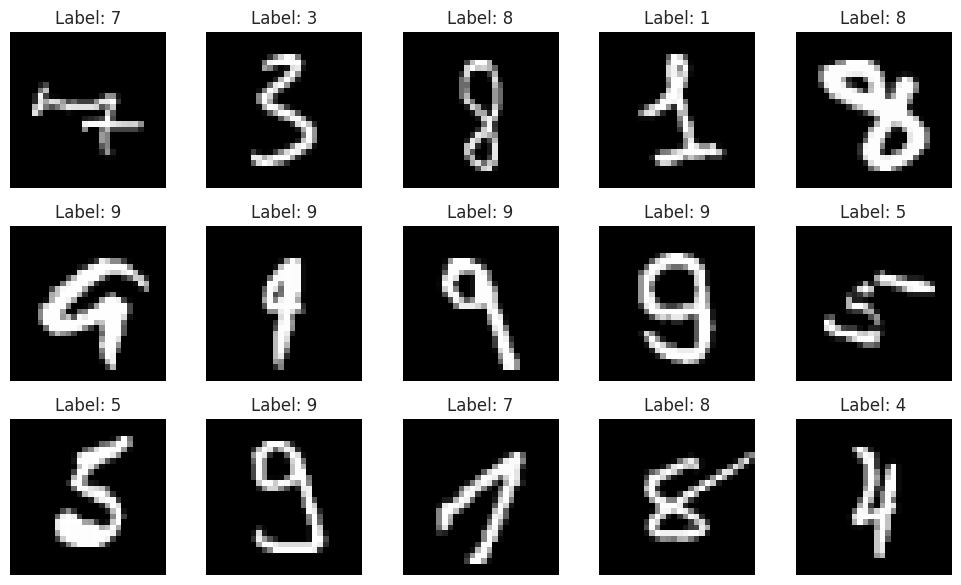

True → Pred
7 → 4  3 → 5  8 → 5  1 → 5  8 → 3  9 → 4  9 → 1  9 → 3  9 → 8  5 → 0  5 → 6  9 → 3  7 → 3  8 → 5  4 → 1  

In [8]:
miss_idx = np.where(y_test != y_pred)[0]
np.random.shuffle(miss_idx)
plot_digits(X_test, y_test, miss_idx[:15], cols=5)

# Show predicted vs true for those 15
print("True → Pred")
for i in miss_idx[:15]:
    print(f"{y_test[i]} → {y_pred[i]}", end='  ')

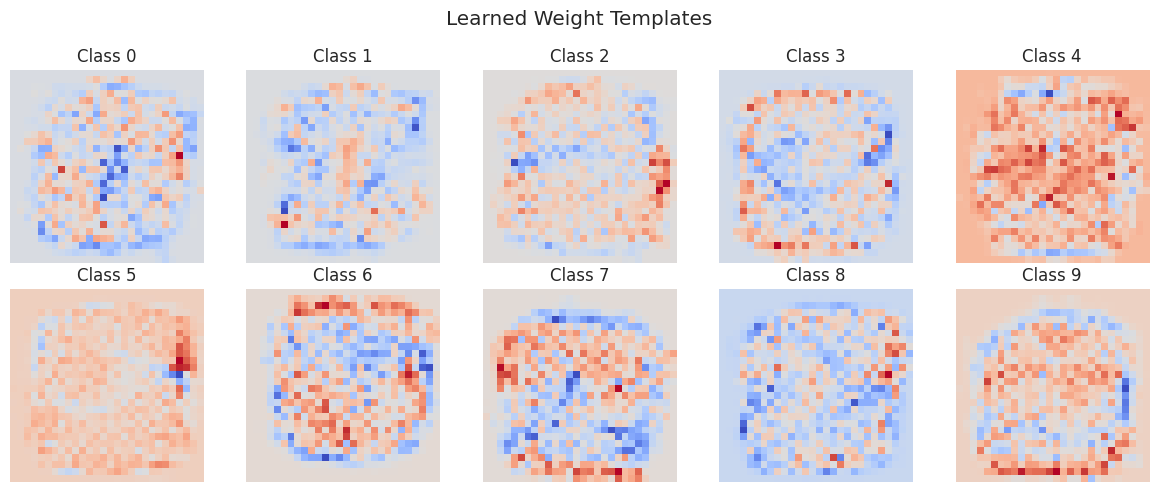

In [9]:
weights = logreg.coef_   # shape (10, 784)
fig, axes = plt.subplots(2, 5, figsize=(12,5))
for digit in range(10):
    ax = axes[digit//5, digit%5]
    ax.imshow(weights[digit].reshape(28,28), cmap='coolwarm')
    ax.set_title(f'Class {digit}')
    ax.axis('off')
plt.suptitle('Learned Weight Templates')
plt.tight_layout()
plt.show()

In [10]:
from collections import defaultdict

error_details = defaultdict(list)
for i in miss_idx:
    true = y_test[i]
    pred = y_pred[i]
    error_details[(true, pred)].append(i)

# Show the **most frequent** confusions
sorted_errors = sorted(error_details.items(),
                       key=lambda x: len(x[1]), reverse=True)[:10]

print("Top 10 confusions (true → pred, count):")
for (true, pred), idxs in sorted_errors:
    print(f"{true} → {pred}: {len(idxs)} times")

Top 10 confusions (true → pred, count):
3 → 5: 40 times
4 → 9: 37 times
8 → 3: 34 times
8 → 5: 31 times
9 → 4: 27 times
5 → 8: 27 times
5 → 3: 27 times
3 → 2: 25 times
7 → 9: 25 times
3 → 8: 24 times


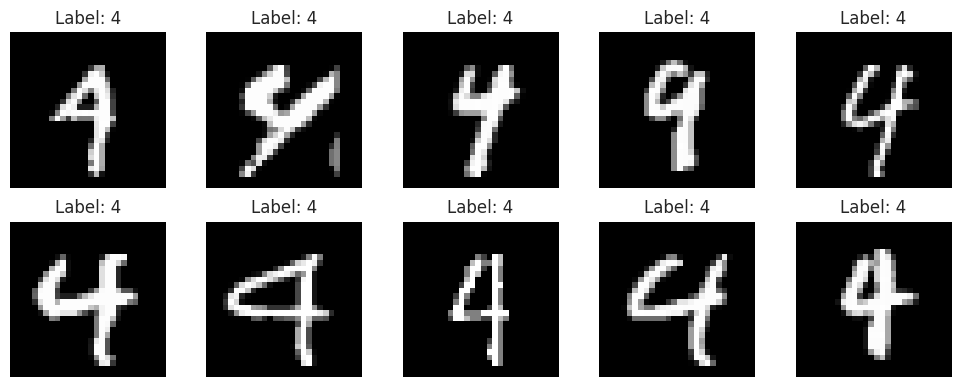

<Figure size 640x480 with 0 Axes>

In [11]:
confused_idx = error_details[(4,9)][:10]
plot_digits(X_test, y_test, confused_idx, cols=5)
plt.suptitle("True label = 4, predicted = 9")
plt.show()

In [ ]:
# -------------------------------------------------
#  Digit Recognition Pipeline with Logistic Regression
# -------------------------------------------------
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# 1. Load data
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data / 255.0, mnist.target.astype(int)

# 2. Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# 3. Train
model = LogisticRegression(multi_class='multinomial',
                           solver='saga', max_iter=1000,
                           n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluate
y_pred = model.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=4))

# 5. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()

# 6. Mis-classified examples
miss = np.where(y_test != y_pred)[0]
np.random.shuffle(miss)
def plot(X, idxs, cols=5):
    rows = (len(idxs)+cols-1)//cols
    plt.figure(figsize=(cols*2, rows*2))
    for i, ix in enumerate(idxs):
        plt.subplot(rows, cols, i+1)
        plt.imshow(X[ix].reshape(28,28), cmap='gray')
        plt.title(f'T:{y_test[ix]} P:{y_pred[ix]}')
        plt.axis('off')
    plt.tight_layout(); plt.show()
plot(X_test, miss[:15])

# 7. Weight templates
w = model.coef_
fig, ax = plt.subplots(2,5,figsize=(12,5))
for d in range(10):
    ax[d//5, d%5].imshow(w[d].reshape(28,28), cmap='coolwarm')
    ax[d//5, d%5].set_title(d); ax[d//5, d%5].axis('off')
plt.suptitle('Class Templates'); plt.tight_layout(); plt.show()